# Plot zonal annual mean NOy

---

Create date: 2025-08-19

Plot zonal mean of NOy from Ozone investigation [Ticket link](https://code.metoffice.gov.uk/trac/UKESM/wiki/1016_Simulations)


In [ ]:
import xarray as xr
import sys
import matplotlib.pyplot as plt

# modules from this directory
sys.path.append("../../")
import src.const as CONST
from src.util.load_data import load_um_data

In [2]:
stashes = [
    "50290",
    "50654",
    "50291",
    "50873",
    "50914",
]

data_path = "/work/scratch-pw2/vs480/nc_files/u-bv828"

In [3]:
datasets = {}

datasets["exp11"] = load_um_data(
    data_path=data_path, stash_list=stashes, engine="netcdf4"
)

Loading files from /work/scratch-pw2/vs480/nc_files/u-bv828 with stashes ['50290', '50654', '50291', '50873', '50914']


## 1. prepare dataset

Rename stashes


In [5]:
rename_dict = {
    "m01s50i290": "bimol85_1",
    "m01s50i291": "het4",
    "m01s50i654": "bimol85_2",
    "m01s50i873": "drydep",
    "m01s50i914": "wetdep",
}

In [8]:
for d, dataset in datasets.items():
    datasets[d] = datasets[d].rename(rename_dict)

In [ ]:
fluxes = ["bimol85_1", "het4", "bimol85_2"]
deps = ["drydep", "wetdep"]

timeslices = {1990: slice("1990-01-01", "1999-12-31")}

In [23]:
datasets_zonal = {d: xr.Dataset() for d in datasets.keys()}

In [24]:
# Flux unit: moles/gridbox/s

In [68]:
time = timeslices[1990]
m_n2o5 = 108.01e-3
for d, dataset in datasets.items():
    for variable in fluxes:
        datasets_zonal[f"{d}"][variable] = (
            (dataset[variable].sel(time=time).mean(dim="time").sum(dim="lon").load())
            * m_n2o5
            * CONST.S2YR
            * 1e-9
        )  # Tg N2O5
        datasets_zonal[d][f"{variable}_rate"] = (
            dataset[variable].sel(time=time).mean(dim=["time", "lon"]).load()
        )  # mol/s

In [59]:
def create_custom_subplots(
    fig_width, widths_subplot, heights_subplot, exclude_bottom_rows: int = 0
):

    fig = plt.figure(figsize=(fig_width, 0.7 * fig_width))

    nrow = len(heights_subplot)
    ncol = len(widths_subplot)

    gs = fig.add_gridspec(
        nrow, ncol, width_ratios=widths_subplot, height_ratios=heights_subplot
    )

    if nrow - exclude_bottom_rows < 0:
        raise ValueError("nrow < 0")

    axs = [
        fig.add_subplot(gs[i, j])
        for i in range(nrow - exclude_bottom_rows)
        for j in range(ncol)
    ]

    return fig, axs, gs, nrow, ncol

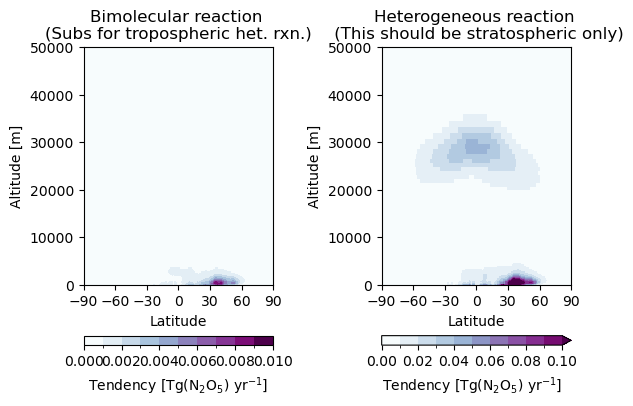

In [ ]:
d = "exp11"

fig, axs, gs, nrow, ncol = create_custom_subplots(
    fig_width=6, widths_subplot=[1, 1], heights_subplot=[1], exclude_bottom_rows=0
)
variables = ["bimol85_1", "het4"]
for ax, variable in zip(axs, variables):
    if variable == "bimol85_1":
        vmax = 0.01
        title = "Bimolecular reaction \n(Subs for tropospheric het. rxn.)"
    else:
        vmax = 0.1
        title = "Heterogeneous reaction \n (This should be stratospheric only)"
    datasets_zonal[d][variable].plot(
        ax=ax,
        y="level_height",
        cmap=plt.cm.BuPu,
        vmax=vmax,
        levels=11,
        cbar_kwargs={
            "orientation": "horizontal",
            "label": "Tendency [Tg(N$_2$O$_5$) yr$^{-1}$]",
        },
    )
    ax.set_title(title)
    ax.set_ylim(0, 50000)
    ax.set_xticks(range(-90, 91, 30))
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Altitude [m]")

fig.tight_layout()

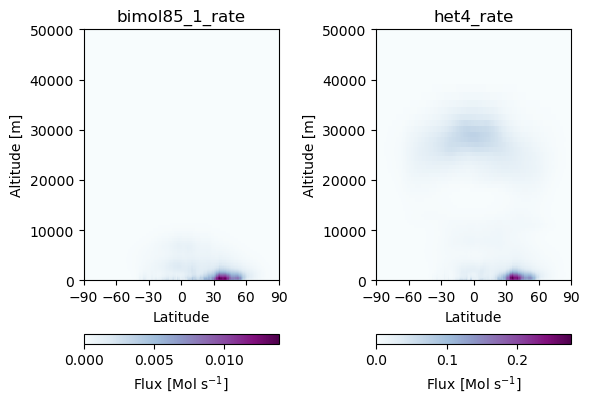

In [71]:
d = "exp11"

fig, axs, gs, nrow, ncol = create_custom_subplots(
    fig_width=6, widths_subplot=[1, 1], heights_subplot=[1], exclude_bottom_rows=0
)
variables = ["bimol85_1_rate", "het4_rate"]
for ax, variable in zip(axs, variables):
    datasets_zonal[d][variable].plot(
        ax=ax,
        y="level_height",
        cmap=plt.cm.BuPu,
        # vmax=0.05,
        cbar_kwargs={
            "orientation": "horizontal",
            "label": "Flux [Mol s$^{-1}$]",
        },
    )
    ax.set_title(variable)
    ax.set_ylim(0, 50000)
    ax.set_xticks(range(-90, 91, 30))
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Altitude [m]")

fig.tight_layout()

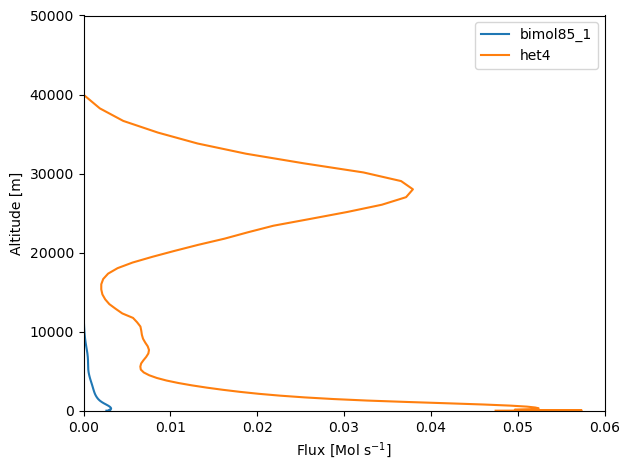

In [89]:
d = "exp11"
time = timeslices[1990]
fig, axs = plt.subplots()
variables = ["bimol85_1", "het4"]
for variable in variables:
    datasets[d][variable].sel(time=time).weighted(datasets[d]["vol_theta"]).mean(
        dim=["lat", "lon", "time"],
    ).plot(y="level_height", label=variable)

axs.set_title(variable)
axs.set_ylim(0, 50000)
# ax.set_xticks(range(-90, 91, 30))
# ax.set_xlabel("Latitude")
axs.set_ylabel("Altitude [m]")
axs.set_xlim(0, 0.06)
axs.set_xlabel("Flux [Mol s$^{-1}$]")
axs.set_title("")
axs.legend()
fig.tight_layout()